In [49]:
import xarray as xr
import numpy as np

In [50]:
file = "/nird/projects/NS1004K/elihho/VolcanEESMv3.11_SO2_850-2016_Mscale_Zreduc_1deg_c180812.nc"
ds = xr.open_dataset(file, decode_times=False)

In [51]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:       (altitude_int: 31, time: 1374, altitude: 30, lat: 192,
                   lon: 288)
Coordinates:
  * altitude_int  (altitude_int) float32 124B -0.5 0.5 1.5 ... 27.5 28.5 29.5
  * altitude      (altitude) float32 120B 0.0 1.0 2.0 3.0 ... 27.0 28.0 29.0
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Dimensions without coordinates: time
Data variables:
    date          (time) float64 11kB ...
    datesec       (time) float64 11kB ...
    stratvolc     (time, altitude, lat, lon) float32 9GB ...
Attributes:
    filename:           \nVolcanEESMv3.11_SO2_850-2016_Mscale_Zreduc_1deg_c18...
    title:              \nSO2 emissions from stratospheric volcanoes, 853.5.2...
    data_creator:       \nRyan Neely, University of Leeds, UK, earrn@leeds.ac...
    data_doi:           \n10.5285/76ebdc0b-0eed-4f70-b89e-55e606bcd568
    data_source_url:    \nhttp://catalogue.ceda.ac.uk/uuid/bfbd5ec825fa422f9a...
    data_reference:     \nMills, M. J. et al. (2016), Global volcanic aerosol...
    data_source_files:  \n/glade/work/mmills/data/VolcanEESM/volcan-eesm_glob...
    creation_date:      \nSun Aug 12 23:37:42 MDT 2018
    cesm_contact:       \nMike Mills, NCAR ACOM, mmills@ucar.edu
    data_script:        \nConverted from data_source_files by program /glade/...
    input_method:       SERIAL
    data_summary:       \nEach day of eruption, the emission occurs over 6 ho...

In [52]:
print(ds["stratvolc"].dims)

('time', 'altitude', 'lat', 'lon')


In [53]:
"""txt = ds.attrs["data_summary"]
txt = txt.replace("19910615  15.130 120.350", "19910615  64 341")

ds.attrs["data_summary"] = txt"""

'txt = ds.attrs["data_summary"]\ntxt = txt.replace("19910615  15.130 120.350", "19910615  64 341")\n\nds.attrs["data_summary"] = txt'

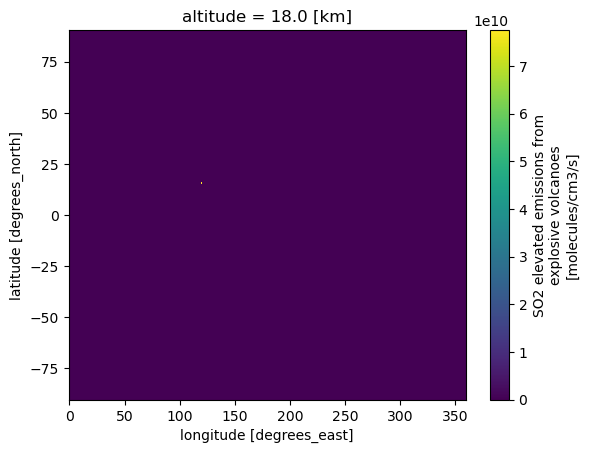

In [54]:
a=np.where(ds.date.values == 19910615)
aa = ds.stratvolc.sel(time=a[0][1],altitude=21)
ds.stratvolc.sel(time=a[0][1],altitude=18).plot()
#ds.datesec.where(ds.date==a[0][0])

In [55]:
new_lat = 64.0
new_lon = 341.0  

time_idx = ds.get_index('time').get_indexer([a[0][1]], method='nearest')[0]
lat_idx  = int(np.abs(ds['lat'].values - new_lat).argmin())
lon_idx  = int(np.abs(ds['lon'].values - new_lon).argmin())

assert ds['stratvolc'].dims == ('time','altitude','lat','lon')
assert 0 <= time_idx < ds.dims['time']
assert 0 <= lat_idx  < ds.dims['lat']
assert 0 <= lon_idx  < ds.dims['lon']

field2d = ds['stratvolc'].isel(time=time_idx).sum('altitude')  # (lat, lon)
old_lat_idx, old_lon_idx = np.unravel_index(
    np.nanargmax(field2d.values), field2d.shape
)

col_old = ds['stratvolc'].isel(time=time_idx, lat=old_lat_idx, lon=old_lon_idx).values
ds['stratvolc'][time_idx, :, lat_idx, lon_idx] = col_old

ds['stratvolc'][time_idx, :, old_lat_idx, old_lon_idx] = 0.0



/tmp/ipykernel_702637/360056528.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert 0 <= time_idx < ds.dims['time']
/tmp/ipykernel_702637/360056528.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert 0 <= lat_idx  < ds.dims['lat']
/tmp/ipykernel_702637/360056528.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert 0 <= lon_idx  < ds.dims['lon']


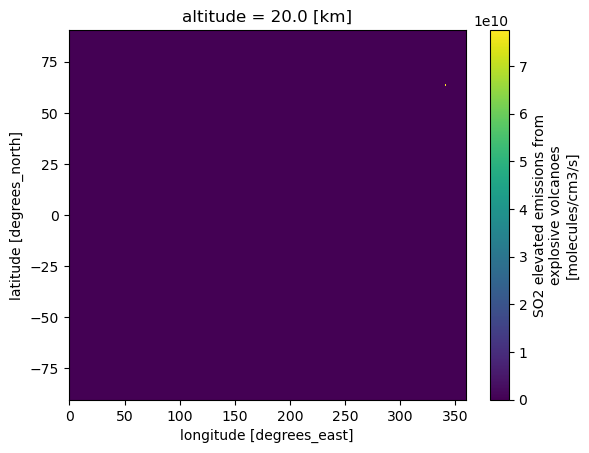

In [56]:
ds.stratvolc.sel(time=a[0][1],altitude=20).plot()

In [57]:
ds.to_netcdf("/nird/projects/NS1004K/elihho/VolcanEESMv3.11_SO2_pinatubo_moved2iceland.nc")
ds.close()